<details>
  <summary><strong>MIT License（クリックで展開）</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>

# アヤメの分類（機械学習：決定木分類モデル）

## 目的：アヤメという花の品種を分類すること
使える情報（入力データの種類）：「萼片の長さ」「萼片の幅」「花弁の長さ」「花弁の幅」<br>
分類する品種（出力データの種類）：「setosa（ヒオウギアヤメ）」「Versicolor（ブルーフラッグ）」「Virginica（ヴァージニカ）」<br>
データ件数：150（各50）

「アヤメのデータセット」は，機械学習などにおける多クラス分類の練習問題として，しばしば使用されるデータセットです．
幾つかのPythonのライブラリではお試し用のデータとして簡単に使用できるようになっています．

http://archive.ics.uci.edu/ml/datasets/Iris （ライセンス：[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/deed.ja)）

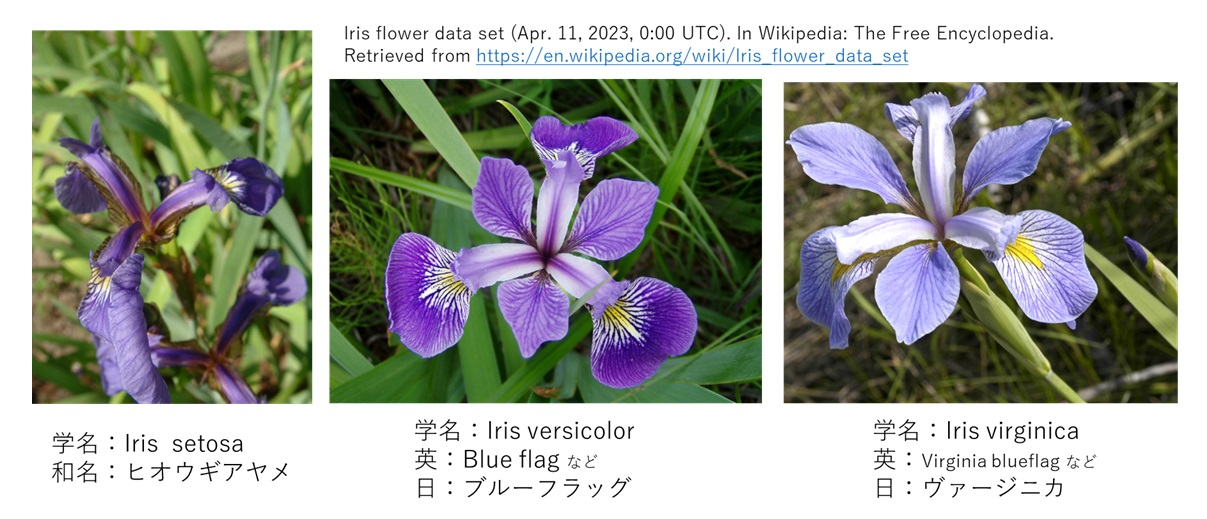

## ライブラリ準備

外部ライブラリかつColab起動時に導入されていないライブラリをインストールする

In [ ]:
import sklearn
import os


# colab にプリインストールされていないライブラリを導入

!pip install -q dtreeviz==2.2.2 # 決定木分類モデルをきれいに可視化するライブラリ
!pip install -q japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

print('scikit-learn version:',sklearn.__version__)

restart_flag = False


if sklearn.__version__ != '1.6.1':
    !pip install -q --upgrade scikit-learn==1.6.1
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

# 以下は，ライブラリのバージョンが変更された場合のみ実行されます．
if restart_flag :
    print("ライブラリバージョンを変更した場合に，自動でランタイムを再起動します．")
    print("colabの場合は【不明な理由でクラッシュした】旨の警告が左下に出てきますが，")
    print("これは無視しても問題ないので次以降のコードセルを実行してください．")
    # ランタイムを再起動させるために，わざとクラッシュさせています．
    get_ipython().kernel.do_shutdown(restart=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 45.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
scikit-learn version: 1.6.1


ライブラリのインポート

In [ ]:
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
import matplotlib.pyplot as plt # matplotlib：グラフ描画用ライブラリの一つ
plt.set_loglevel("error") #警告抑制のため

import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
import dtreeviz # dtreeviz：決定木分類モデルをきれいに可視化するライブラリの一つ
import japanize_matplotlib # matplotlibの日本語化用ライブラリ

# scikit_learn：機械学習用のライブラリの一つ
from sklearn.model_selection import train_test_split
from sklearn.metrics import  classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
from sklearn.model_selection import LearningCurveDisplay

In [ ]:
print('初期設定の最大表示行数：',pd.get_option('display.max_rows'))

# 表形式で表示するとき，省略させずに表示する最大の行数を設定する
pd.set_option('display.max_rows', 150)

print('変更後の最大表示行数：',pd.get_option('display.max_rows'))


初期設定の最大表示行数： 60
変更後の最大表示行数： 150


## データの確認

In [ ]:
# iris dataset（アヤメのデータセット）を読み込む
iris = sns.load_dataset('iris')

print(iris.info())
# 先頭10行を表示
display(iris.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
# 日本語の列名へ変更
iris.columns = ['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅','種別']

In [ ]:
print(iris.info())
# 全ての行を表示
display(iris)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   萼片の長さ   150 non-null    float64
 1   萼片の幅    150 non-null    float64
 2   花弁の長さ   150 non-null    float64
 3   花弁の幅    150 non-null    float64
 4   種別      150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,萼片の長さ,萼片の幅,花弁の長さ,花弁の幅,種別
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### 統計量の出力

In [ ]:
# 統計量を出力
display(iris.describe())

,萼片の長さ,萼片の幅,花弁の長さ,花弁の幅
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### ペアプロット図の出力

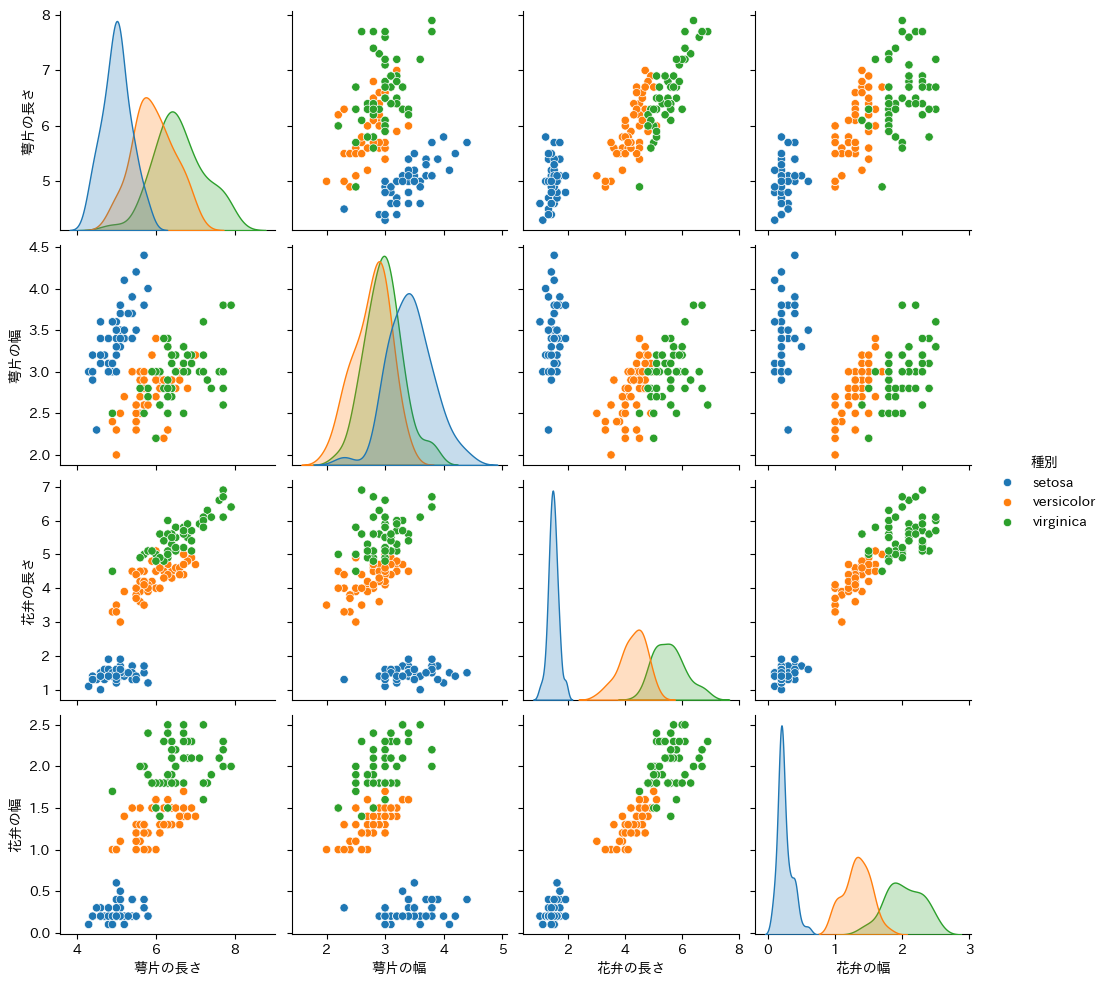

In [ ]:
# irisデータセットの散布図行列を描画する
# 各列同士の散布図が行列のように配置された，ペアプロット図を作成する．なお，対角線の位置には密度分布かヒストグラムが描画される．
sns.pairplot(iris, hue='種別')
plt.show()

setora（ヒオウギアヤメ）は，他2種と直線で分離できそうなことが分かります．<br>
特に，花弁の長さ と 花弁の幅 が顕著で，花弁の長さ は 約 2.3 ， 花弁の幅 は 約 0.8 くらいで，setora（ヒオウギアヤメ）と他2種を分離できそうです．<br>
一方，他の2種は点が重なり合っていて，単純に分離するのは難しそうであることが分かります．<br>

In [ ]:
# 花弁の長さが 2.3 未満であれば setora（ヒオウギアヤメ）
display( iris[ iris['花弁の長さ'] < 2.3 ] )

,萼片の長さ,萼片の幅,花弁の長さ,花弁の幅,種別
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### 円グラフの出力

各種別毎のデータ数の割合を確認してみましょう．<br>
このデータセットは各種別毎のデータ数が同じであり，均衡データであることが分かります．


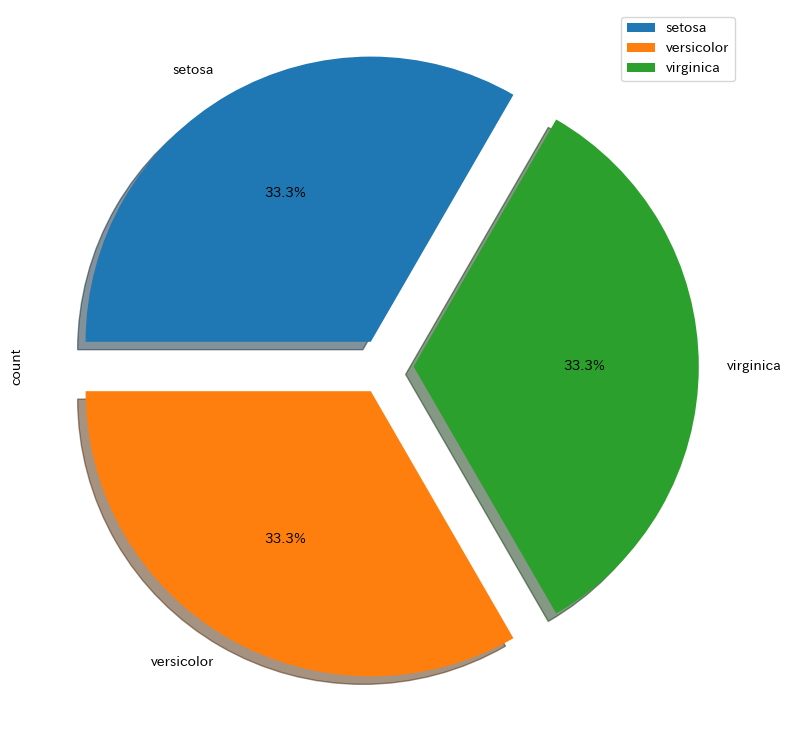

In [ ]:
iris['種別'].value_counts().plot.pie(explode=[0.1,0.1,0.1],autopct='%1.1f%%',shadow=True, figsize=(8,8), startangle=60)
plt.legend()
plt.tight_layout()
plt.show()

## Scikit-learn（決定木分類）

機械学習で用いられるアルゴリズムには，多くの種類・系統があります．

今回はその内の1つ，「**決定木（Decision tree）**」と呼ばれる系統に類するアルゴリズムを使用します．

決定木は，下記のような **木構造** と呼ばれる構造に着想を得たアルゴリズムです．

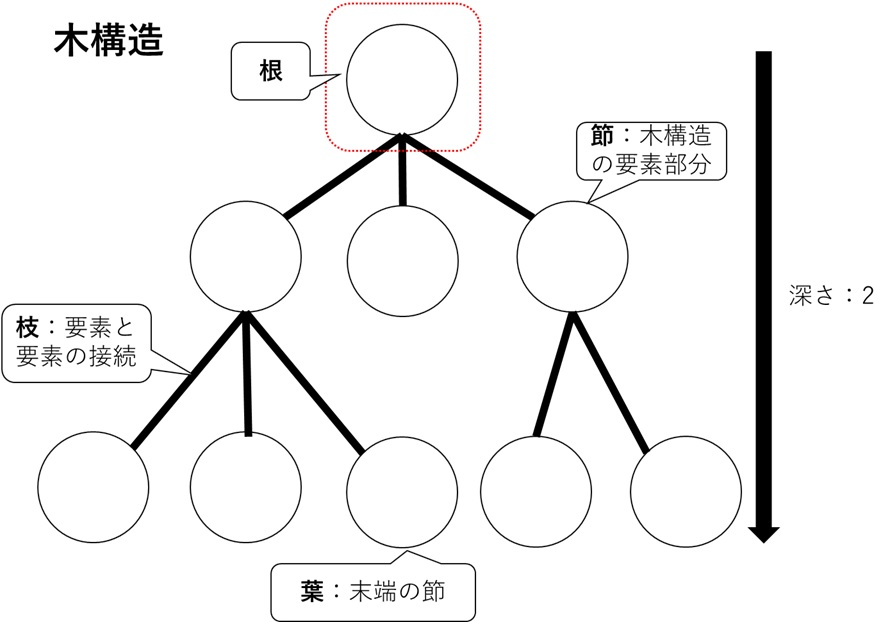



決定木系統のアルゴリズムにおける利点は，次の通りです．

1.   どのように分類されたのかが明瞭に解釈しやすい（モデル内部を可視化できる）．
2.   説明変数も目的変数でも，尺度を問わず扱うことができる．
>* 尺度：名義尺度，順序尺度，間隔尺度，比例尺度
3.   外れ値に対して比較的頑健である．

逆に，欠点は次の通りです．

1.   性能はそれほどよくない．
>* 昨今はこれよりも性能が良いアルゴリズムがあります．ただし，性能が良いアルゴリズムは，解釈性が落ちることが多いです．
2.   過学習を起こしやすい．
>*   過学習を防ぐための，パラメータ調整が必要です．
>*   決定木において過学習を防ぐために行われる調整としては，木の深さを制限する（通称：「剪定」）ことなどが挙げられます．
3.   説明変数と目的変数が線型関係にあるデータには，それほど適していない．
>*   決定木は非線型モデルです．線型性のあるデータを表現できないわけではないですが，過学習を起こしやすくなります．
4.  ノード間の接続は AND のみ．
5.  ...

など．


### 名義尺度の数値化（ラベルエンコーディング）

花の種別は，名義尺度のカテゴリデータです．データ分析や機械学習アルゴリズムで使用するにあたり，この文字列の数値化を行います．

>※ 現行バージョンのscikit-learnライブラリにおける決定木分類モデルでは，名義尺度を数値化しなくても動作します．しかし，数値化しなくては動かない外部ライブラリもあるため，今回は練習のためにラベルエンコーディングによる数値化を行います．

>※ 名義尺度を数値化する場合，使用する機械学習モデルのアルゴリズムによっては，One-hot-encoding（ワンホットエンコーディング）という前処理が必要です．ただし，決定木分類モデルでは例外的に不要であるため，今回は説明しません．

In [ ]:
# 「種別」が文字列となっている
display(iris.head(5))
display(iris['種別'].values)

,萼片の長さ,萼片の幅,花弁の長さ,花弁の幅,種別
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ラベルエンコーディングを行うための準備
le = LabelEncoder()
# 「種別」列に対して，ラベルエンコーディングを行い，iris_label_encodedへ格納
iris_label_encoded = le.fit_transform(iris['種別'].values)
# iris_label_encodedを出力
display( iris_label_encoded )

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### 訓練データとテストデータへ分割

In [ ]:
# X : 入力データ
X = iris[ ['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅'] ].values
# Y：出力データ（ラベルエンコーディング後）
Y = le.fit_transform(iris['種別'].values)

# train ：訓練データ
# test：テストデータ
# ランダムに分割する
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=333)

In [ ]:
# X_train の中身を確認
print(X_train)

[[6.3 2.9 5.6 1.8]
 [5.6 2.5 3.9 1.1]
 [5.1 3.5 1.4 0.3]
 [6.5 3.  5.2 2. ]
 [6.6 3.  4.4 1.4]
 [5.8 2.8 5.1 2.4]
 [4.6 3.6 1.  0.2]
 [6.7 2.5 5.8 1.8]
 [7.9 3.8 6.4 2. ]
 [4.4 3.2 1.3 0.2]
 [6.3 2.8 5.1 1.5]
 [4.8 3.1 1.6 0.2]
 [5.9 3.  4.2 1.5]
 [7.7 2.8 6.7 2. ]
 [4.4 2.9 1.4 0.2]
 [5.8 4.  1.2 0.2]
 [5.8 2.7 3.9 1.2]
 [5.3 3.7 1.5 0.2]
 [6.6 2.9 4.6 1.3]
 [5.1 3.4 1.5 0.2]
 [6.2 2.2 4.5 1.5]
 [5.4 3.9 1.3 0.4]
 [6.1 2.8 4.7 1.2]
 [5.6 2.8 4.9 2. ]
 [6.4 3.2 5.3 2.3]
 [7.4 2.8 6.1 1.9]
 [5.1 3.8 1.9 0.4]
 [5.  3.6 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  2.3 3.3 1. ]
 [7.7 3.8 6.7 2.2]
 [7.1 3.  5.9 2.1]
 [6.9 3.1 5.1 2.3]
 [4.8 3.4 1.6 0.2]
 [4.9 3.1 1.5 0.1]
 [6.5 3.  5.8 2.2]
 [5.5 2.4 3.8 1.1]
 [4.9 3.  1.4 0.2]
 [6.8 2.8 4.8 1.4]
 [4.8 3.  1.4 0.3]
 [5.  3.3 1.4 0.2]
 [6.9 3.1 4.9 1.5]
 [6.8 3.2 5.9 2.3]
 [5.  2.  3.5 1. ]
 [6.7 3.1 4.7 1.5]
 [5.  3.  1.6 0.2]
 [5.7 2.8 4.1 1.3]
 [5.4 3.  4.5 1.5]
 [5.4 3.7 1.5 0.2]
 [5.7 2.5 5.  2. ]
 [6.1 2.6 5.6 1.4]
 [5.1 3.5 1.4 0.2]
 [5.2 2.7 3.

In [ ]:
# Y_train の中身を確認
print(Y_train)

[2 1 0 2 1 2 0 2 2 0 2 0 1 2 0 0 1 0 1 0 1 0 1 2 2 2 0 0 0 1 2 2 2 0 0 2 1
 0 1 0 0 1 2 1 1 0 1 1 0 2 2 0 1 1 1 2 0 2 0 1 1 1 2 2 0 1 0 0 1 0 0 2 1 0
 1 0 2 2 1 1 2 0 1 1 1 2 2 1 2 0 2 2 2 2 0 1 2 0 1 1 0 0 2 2 0]


### 決定木分類モデルの作成と訓練
決定木分類モデルを作成します．
下記のような，モデルの作成時に人間が調整するパラメータを**ハイパーパラメータ**と呼びます．機械学習においては，ハイパーパラメータの調整によって生成されるモデルの性能が変わることもあります．

In [ ]:
# 決定木分類モデルを作成する
DT = tree.DecisionTreeClassifier(
    criterion = 'gini', # 'gini', 'entropy', 'log_loss' のいずれか
    splitter = 'best', # 'best'か'random'
    max_depth = None, # 正の整数，分割の深さの最大値
    min_samples_split = 2, # 正の整数を推奨，0 < min_samples_split < サンプル数，今回は大きくし過ぎると精度が落ちます．
    min_samples_leaf = 1, # 正の整数を推奨，0 < min_samples_leaf < サンプル数，今回は大きくし過ぎると精度が落ちます．
    min_weight_fraction_leaf = 0.0,  #今回は操作しないでください．
    max_features = None, # 今回は，None, 'sqrt', 'log2' のいずれかを選択してください（※今回は None が適しています）．
    random_state = 42, #　正の整数，疑似乱数のシード
    max_leaf_nodes = None, # 正の整数，葉のノード数の最大値
    min_impurity_decrease = 0.0, # 今回は操作しないでください．
    class_weight = None, # 今回は操作しないでください．
    ccp_alpha = 0.0 # 今回は操作しないでください．
)

# 訓練データで決定木分類モデルを訓練させる
DT = DT.fit(X = X_train, # 訓練用データの説明変数
            y = Y_train, # 訓練用データの目的変数
            sample_weight=None, # 今回は操作しないでください．
            check_input=True # 今回は操作しないでください．
            )

下記に，引数の説明を記載します．<br>
より詳しい説明は，[scikit-learnドキュメントWebページ](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)を参照してください．

tree.DecisionTreeClassifier() の引数説明：

|引数名|任意/必須|入力値|備考|
|----|----|----|----|
|criterion| 任意 |'gini', 'entropy','log_loss'　未設定時：'gini'|分割基準の質を数値として表すときの計算手法．選択可能な手法は，ジニ不純物の「gini」，シャノン情報ゲインの「log_loss」または「entropy」．|
|splitter| 任意 |'best', 'random'　未設定時：'best'| 各ノードで分割を選択するために使用される戦略．選択可能な戦略は，最適な分割を選択する```'best'```と，最適なランダム分割を選択する```'random'```．
|max_depth |任意|int，未設定時：None|木の最大深度．```None``` の場合，全ての葉が同じクラスになるまで，あるいは全ての葉に含まれるサンプルが ```min_samples_split``` 未満になるまで，ノードが展開される．|
|min_samples_split|任意| int または float、デフォルト = 2|```min_samples_split```がint型の場合は，その値が内部ノードを分割するために必要なサンプルの最小数と見なされる．<br>```min_samples_split```がfloat型の場合は，```ceil(min_samples_split * n_samples)```であると見なされ，サンプル数によって最小数が変動する．
|min_samples_leaf| 任意| int または float　未設定時：1|葉ノードに必要なサンプルの最小数．任意の深さの分割点は，左右の分岐のそれぞれに少なくとも```min_samples_leaf```以上の 訓練サンプル が残っている場合にのみ考慮される．（回帰モデルにおいては平滑化の効果あり．）<br>```min_samples_leaf```がint型の場合，その値が最小数と見なされる．<br>float型の場合は， ```ceil(min_samples_leaf * n_samples)```であると見なされ，サンプル数によって最小数が変動する．
|min_weight_fraction_leaf|任意| float　未設定時：0.0|**今回は操作しないでください．（重み付けを行わないため）**|
|max_features |任意| int または float または 'sqrt'または'log2'　未設定時：None|最適な分割を探す際に考慮する特徴量の数<br>int型の場合，各分割時に```max_features```個の特徴量を考慮する，<br>float型 の場合， ```max(1, int(max_features * n_features_in_))```であると見なされ，特徴量の数によって変動する．<br>```'sqrt'```の場合，```max_features=sqrt(n_features)```と見做される.<br>```'log2'```の場合、```max_features=log2(n_features)```と見做される．<br>```None```の場合，```max_features=n_features```と見做される．<br>注: ```max_features```の数を超える数の特徴量を効果的に検査する必要がある場合でも，ノード サンプルの有効な分割が少なくとも 1 つ見つかるまで，分割の検索は停止しない．
|random_state|任意| intまたはRandomState インスタンスまたは None　未設定時：None|決定木モデルのランダム性を制御する．<br>Noneの場合，```splitter```が```'best'```に設定されていても，特徴量は常に各分割でランダムに並べ替えられるため，``` max_features <= n_features ```の場合は，実行ごとに「最適な分割」が異なる場合がある．<br>訓練中に決定論的な動作（いつ実行しても同じ結果）を得るには，```random_state``` を整数に固定する必要がある．|
|max_leaf_nodes|任意| int　未設定時：None|ベストファースト（最良優先）方式により， max_leaf_nodes で指定された葉のノード数まで木を成長させる．最良のノードは，不純物の相対的な減少として定義される．None の場合，木の葉のノード数は無制限となる．|
|min_impurity_decrease |任意| float　未設定時：0.0|分割時にこの値以上の不純物の減少を引き起こす場合のみ，ノードが分割される．|
|class_weight|任意| 辞書または辞書のリストまたは'balance'　未設定時：None|**今回は操作しないでください．（重み付けを行わないため）**|
|ccp_alpha|任意| 非負の float，未設定時：0.0|Minimal Cost-Complexity Pruning に使用される複雑さパラメータ．**今回は操作しないでください．**|

### 訓練させた決定木分類モデルで推論する

In [ ]:
# 訓練させた決定木分類モデルでテストデータを推論させる
prediction = DT.predict(X_test)

print('テストデータの推論結果（数値ラベル）：',prediction)

# ラベルエンコーディングを逆変換
print('テストデータの推論結果：',le.inverse_transform(prediction))

テストデータの推論結果（数値ラベル）： [0 2 0 0 0 2 0 1 1 2 2 1 0 2 2 1 0 0 2 2 2 0 1 1 2 2 0 0 1 1 1 0 1 2 2 0 2
 1 2 0 1 1 1 1 2]
テストデータの推論結果： ['setosa' 'virginica' 'setosa' 'setosa' 'setosa' 'virginica' 'setosa'
 'versicolor' 'versicolor' 'virginica' 'virginica' 'versicolor' 'setosa'
 'virginica' 'virginica' 'versicolor' 'setosa' 'setosa' 'virginica'
 'virginica' 'virginica' 'setosa' 'versicolor' 'versicolor' 'virginica'
 'virginica' 'setosa' 'setosa' 'versicolor' 'versicolor' 'versicolor'
 'setosa' 'versicolor' 'virginica' 'virginica' 'setosa' 'virginica'
 'versicolor' 'virginica' 'setosa' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'virginica']


In [ ]:
# テストデータの正解ラベルと，推論結果を比較する
print( classification_report( y_true = Y_test, y_pred = prediction, target_names = iris['種別'].unique() ) )

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.93      0.88      0.90        16
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.93      0.93      0.93        45



In [ ]:
# Accuracy（正解率）を計算する
from sklearn import metrics
print('Accuracy Score:', metrics.accuracy_score( Y_test, prediction))

Accuracy Score: 0.9333333333333333


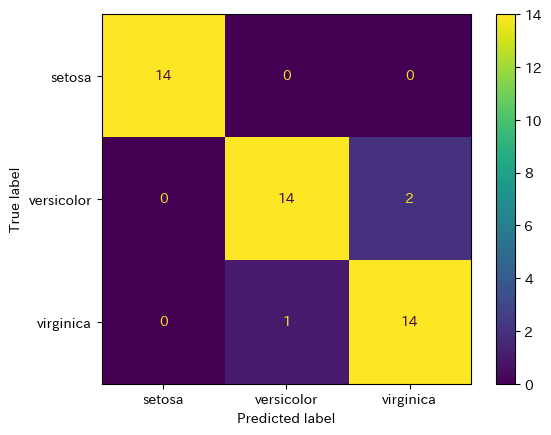

In [ ]:
# 混同行列を描画する
cm = confusion_matrix(Y_test, prediction, labels=DT.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=iris['種別'].unique())
disp.plot()
plt.show()

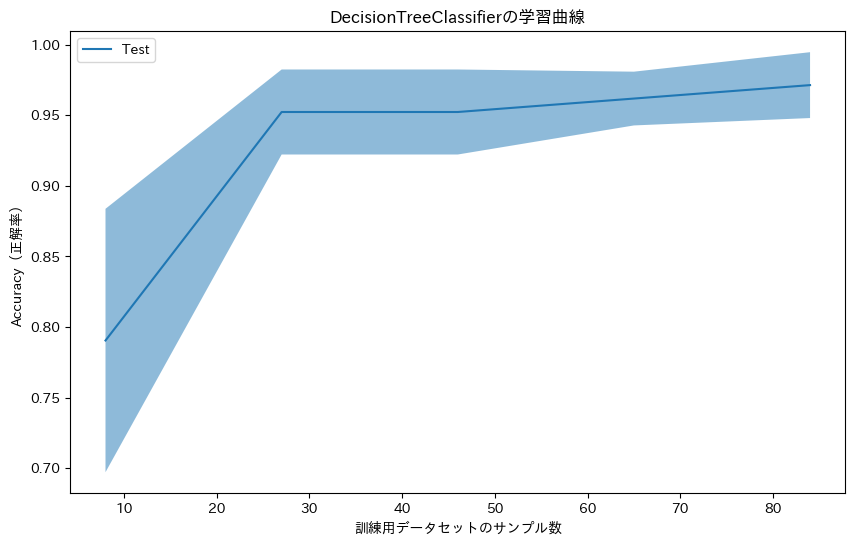

In [ ]:
# 学習曲線を描画する

from sklearn.model_selection import LearningCurveDisplay

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
_ = LearningCurveDisplay.from_estimator(estimator=DT, X=X_train, y=Y_train, \
                                    score_type='test', \
                                    scoring='accuracy', score_name='Accuracy（正解率）', \
                                    ax=ax)
ax.legend()
ax.set_title(f"{DT.__class__.__name__}の学習曲線")
ax.set_xlabel('訓練用データセットのサンプル数')
plt.show()

機械学習において，一般的に，十分な数と質の訓練用データがあれば，精度を上げやすいと言えます．

しかし限度はあり，このアヤメのデータセットの例においては，これ以上は闇雲にデータセットの数を増やしても，精度は頭打ちになってしまう可能性が高いと考えられます．

>※アヤメのデータセットは，機械学習において非常に単純な問題として挙げられる例です．

### 決定木分類モデルを可視化する

#### テキストによる出力

In [ ]:
# テキストファイルによる出力
text_representation = tree.export_text(decision_tree=DT, feature_names= ['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅'] )

with open("./iris_DecisionTree_text.txt", "w") as file:
    file.write(text_representation)

print(text_representation)

|--- 花弁の長さ <= 2.60
|   |--- class: 0
|--- 花弁の長さ >  2.60
|   |--- 花弁の幅 <= 1.65
|   |   |--- 花弁の長さ <= 5.00
|   |   |   |--- class: 1
|   |   |--- 花弁の長さ >  5.00
|   |   |   |--- 萼片の長さ <= 6.05
|   |   |   |   |--- class: 1
|   |   |   |--- 萼片の長さ >  6.05
|   |   |   |   |--- class: 2
|   |--- 花弁の幅 >  1.65
|   |   |--- class: 2



#### dtreevizによる出力

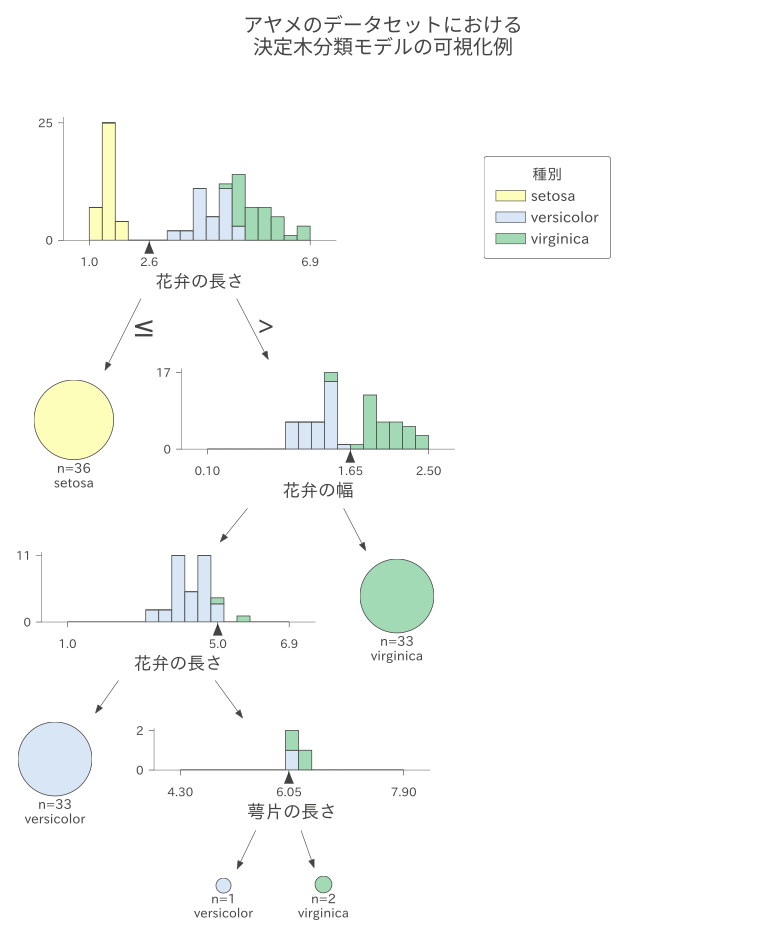

In [ ]:
viz_model = dtreeviz.model(DT,
                           X_train=X_train,
                           y_train=Y_train,
                           feature_names=['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅'],
                           target_name='種別',
                           class_names=iris['種別'].unique().tolist()
                           )

viz_model.view(fontname = 'IPAexGothic', # フォントの指定
               title = 'アヤメのデータセットにおける\n決定木分類モデルの可視化例',#グラフタイトル
               scale = 2.0, # 全体的な文字の大きさの縮尺を指定
               orientation = 'TD', # 木の向きを指定 'TD' もしくは 'LR'
               fancy = True, #特徴量の決定境界を可視化するか否か
               show_root_edge_labels = True, # 根から節への分岐の値関係を表示するか否か
               histtype = 'barstacked', # ヒストグラムの形式：'bar', 'barstacked', 'strip' のいずれか
               leaftype = 'pie' # 葉のグラフ形式；: 'pie', 'barh' のいずれか
               )

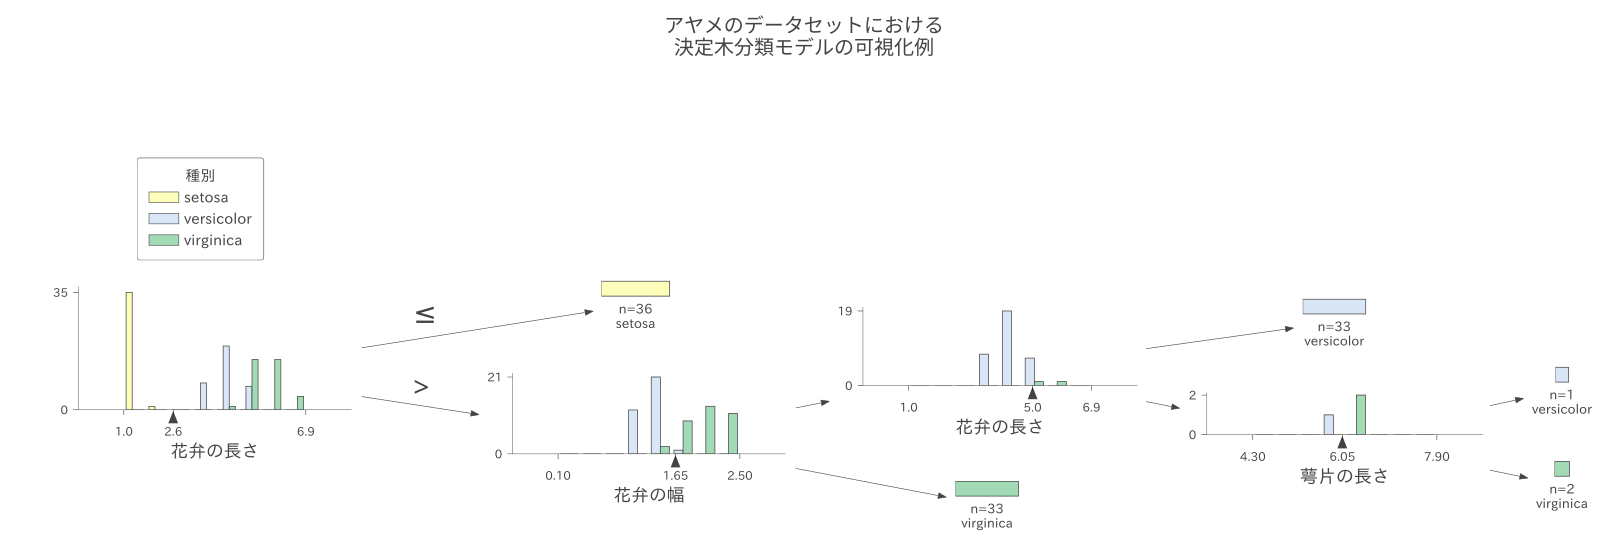

In [ ]:
viz_model.view(fontname = 'IPAexGothic', # フォントの指定
               title = 'アヤメのデータセットにおける\n決定木分類モデルの可視化例',#グラフタイトル
               scale = 2.0, # 全体的な文字の大きさの縮尺を指定
               orientation = 'LR', # 木の向きを指定 'TD' もしくは 'LR'
               fancy = True, #特徴量の決定境界を可視化するか否か
               show_root_edge_labels = True, # 根から節への分岐の値関係を表示するか否か
               histtype = 'bar', # ヒストグラムの形式：'bar', 'barstacked', 'strip' のいずれか
               leaftype = 'barh' # 葉のグラフ形式；: 'pie', 'barh' のいずれか
               )

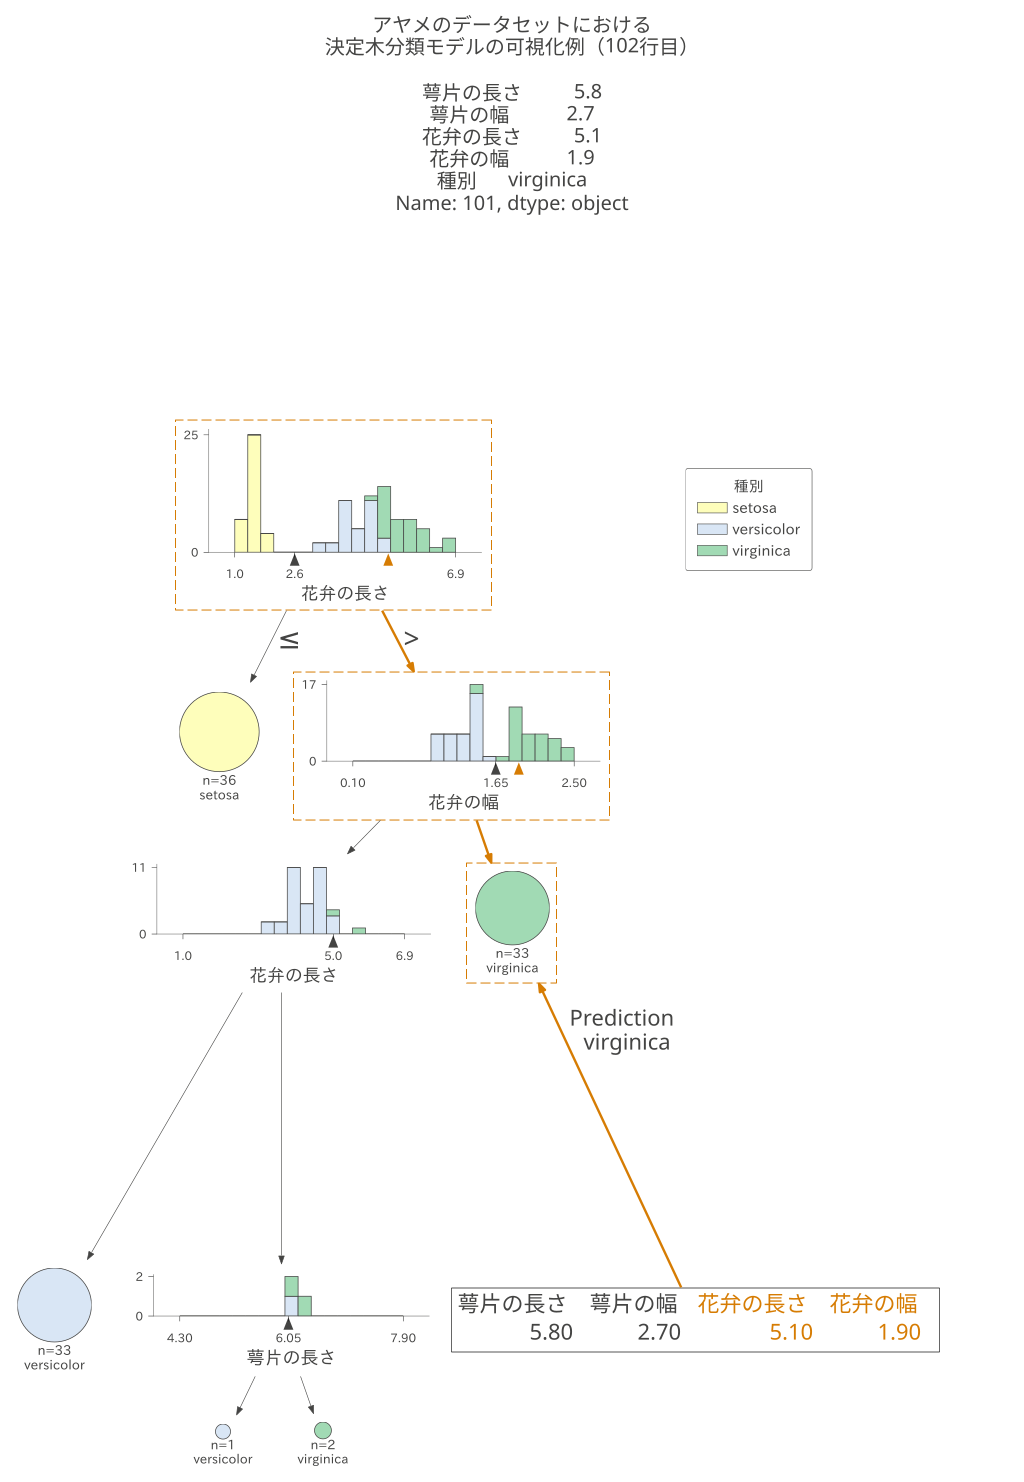

In [ ]:
viz_model = dtreeviz.model(DT,
                           X_train=X_train,
                           y_train=Y_train,
                           feature_names=['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅'],
                           target_name='種別', class_names=iris['種別'].unique().tolist())

viz_model.view(fontname = 'IPAexGothic', # フォントの指定
               title = f'アヤメのデータセットにおける\n決定木分類モデルの可視化例（102行目）\n\n{ iris.loc[101,:] }',#グラフタイトル
               scale = 2.0, # 全体的な文字の大きさの縮尺を指定
               orientation = 'TD', # 木の向きを指定 'TD' もしくは 'LR'
               fancy = True, #特徴量の決定境界を可視化するか否か
               show_root_edge_labels = True, # 根から節への分岐の値関係を表示するか否か
               histtype = 'barstacked', # ヒストグラムの形式：'bar', 'barstacked', 'strip' のいずれか
               leaftype = 'pie', # 葉のグラフ形式；: 'pie', 'barh' のいずれか
               # 特定のデータを指定する（以下は，iris データセットの 102行目のデータ ）
               x = iris.loc[101,['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅']].reset_index(drop=True),
               )

In [ ]:
# 以下，iris データセットの 102行目のデータ
display( iris.loc[101,['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅','種別']].to_frame())

,101
萼片の長さ,5.8
萼片の幅,2.7
花弁の長さ,5.1
花弁の幅,1.9
種別,virginica


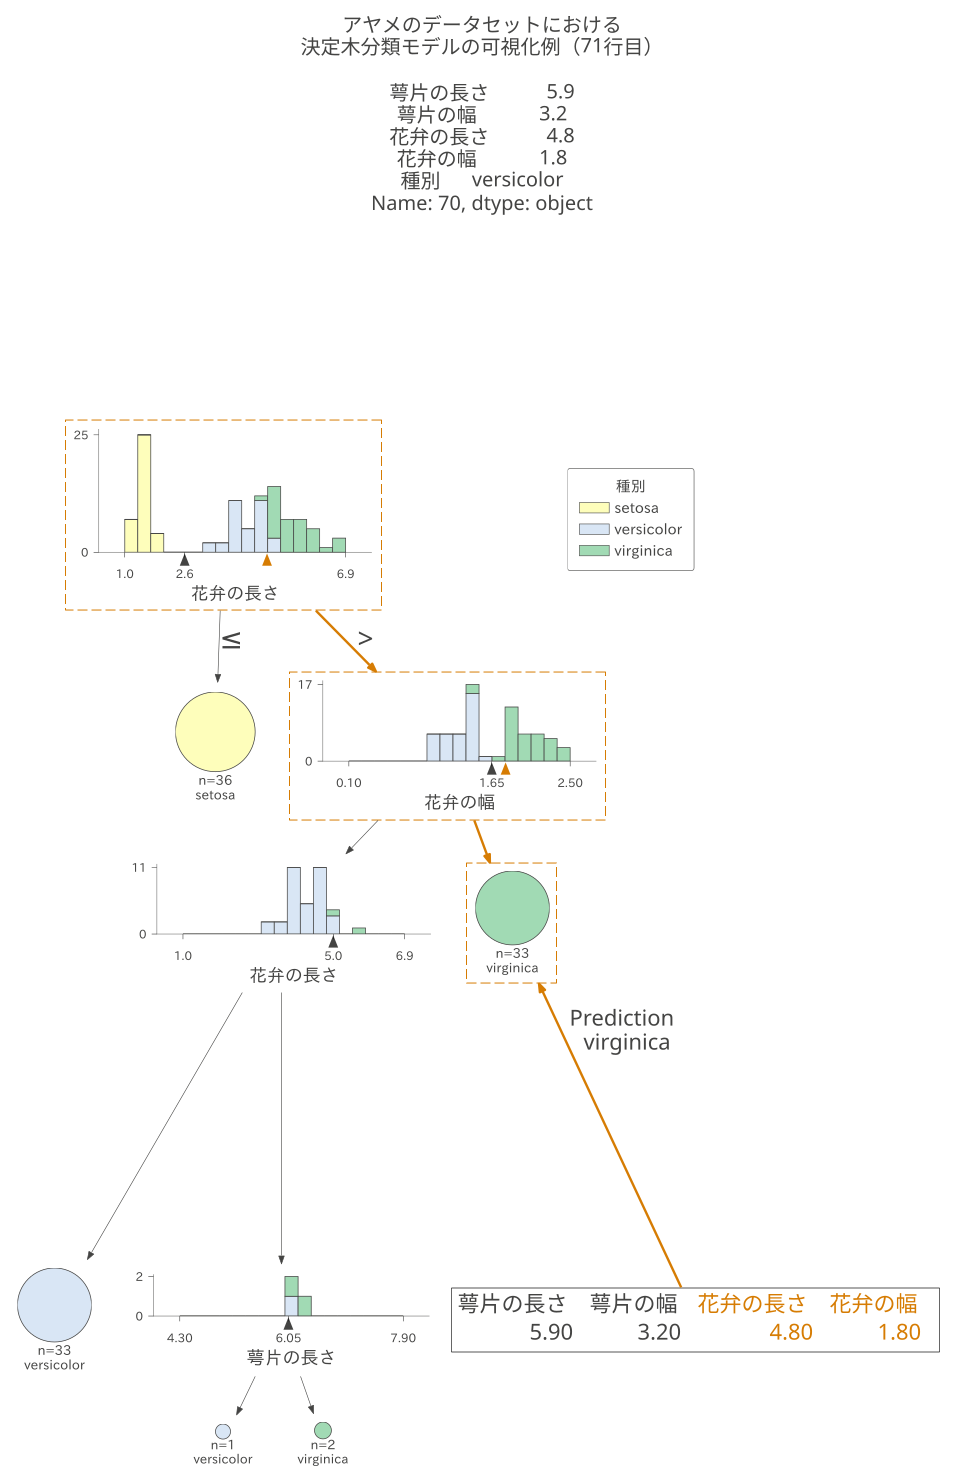

In [ ]:
viz_model = dtreeviz.model(DT,
                           X_train=X_train,
                           y_train=Y_train,
                           feature_names=['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅'],
                           target_name='種別', class_names=iris['種別'].unique().tolist())

viz_model.view(fontname = 'IPAexGothic', # フォントの指定
               title = f'アヤメのデータセットにおける\n決定木分類モデルの可視化例（71行目）\n\n{ iris.loc[70,:] }',#グラフタイトル
               scale = 2.0, # 全体的な文字の大きさの縮尺を指定
               orientation = 'TD', # 木の向きを指定 'TD' もしくは 'LR'
               fancy = True, #特徴量の決定境界を可視化するか否か
               show_root_edge_labels = True, # 根から節への分岐の値関係を表示するか否か
               histtype = 'barstacked', # ヒストグラムの形式：'bar', 'barstacked', 'strip' のいずれか
               leaftype = 'pie', # 葉のグラフ形式；: 'pie', 'barh' のいずれか
               # 特定のデータを指定する（以下は，iris データセットの 71行目のデータ ）
               x = iris.loc[70,['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅']].reset_index(drop=True)
               )

In [ ]:
# 以下，iris データセットの 71行目のデータ
display( iris.loc[70,['萼片の長さ','萼片の幅','花弁の長さ','花弁の幅','種別']].to_frame())

,70
萼片の長さ,5.9
萼片の幅,3.2
花弁の長さ,4.8
花弁の幅,1.8
種別,versicolor


このように，決定木分類モデルは，モデル内部を可視化することで，
**何を基準としてその分類が行われたのか**，を人間が把握することができます．

# 付録：Pythonによるグラフ作成時の文字化け

## 日本語の文字化けについて

matplotlib など，一部のPythonグラフ描画ライブラリでは，日本語に対応していないフォントが初期設定になっている場合があります．
内部で matplotlib が使われているグラフ描画ライブラリの場合は，<br>
matplotlibをインポートする
```
import matplotlub.pylab as plt
```
の後に
```
import japanize_matplotlib
```
をインポートすることで大抵は解決します．Colabには起動時に入っていないライブラリであるため事前に
```
!pip install -q japanize_matplotlib
```
の実行が必要です．

しかし，内部で matplotlib が使われているグラフ描画ライブラリでも，japanize_matplotlib では日本語化（自動で日本語対応フォントへ変更）できない場合ももあります．

日本語に対応していないフォントで無理矢理に日本語を表示すると，下記のような白い四角（通称：「豆腐」）が表示されます．





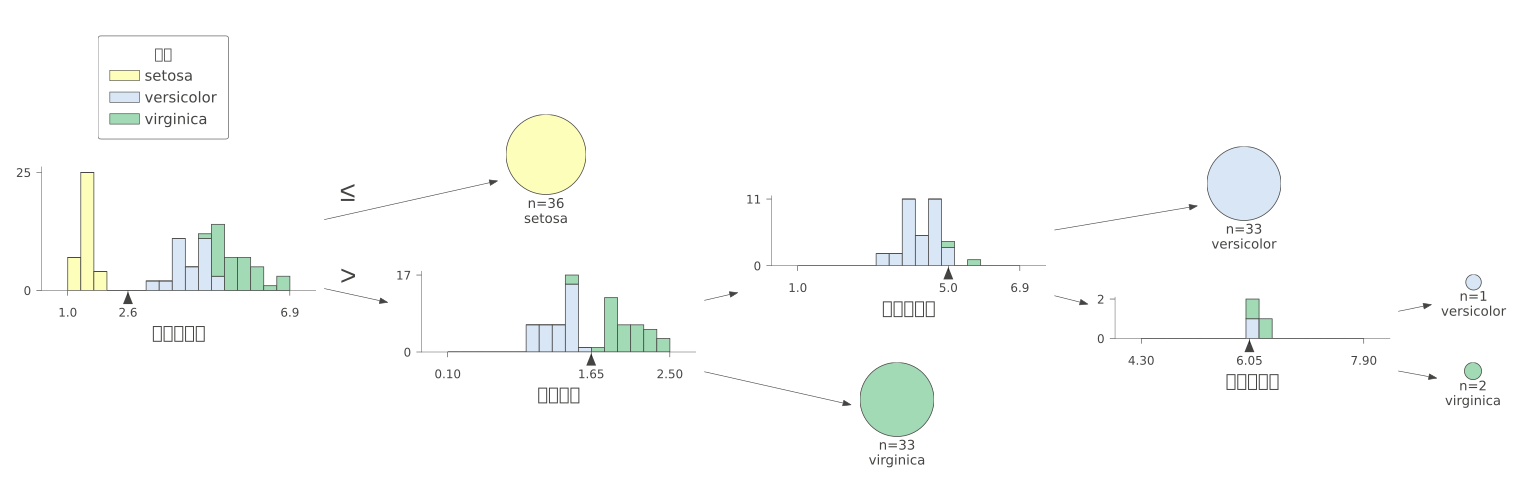

In [ ]:
# 「豆腐」の例
import logging
import warnings
warnings.simplefilter('ignore') # 警告を無視（複数行の警告が出力されるため非表示）
logging.getLogger('matplotlib.font_manager').disabled = True # フォントに関する警告を非表示

viz_model.view(scale=2.0,orientation='LR')

このような場合は，そのライブラリ内で，フォント変更を行う引数を確認する必要があります．

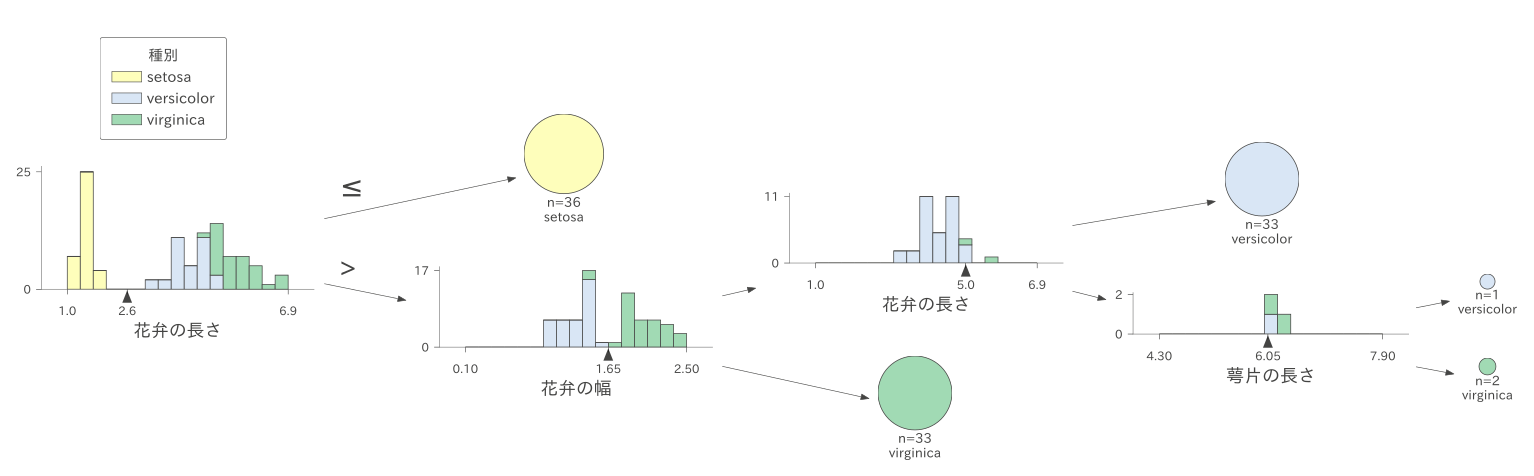

In [ ]:
viz_model.view(fontname='IPAexGothic', #日本語対応フォントを指定
               scale=2.0,
               orientation='LR')

matplotlibで利用可能なフォント一覧を表示します．実行環境（OSなど）で表示可能なフォントが異なるため注意してください．


In [ ]:
import matplotlib.font_manager as fm
import pprint

font_list = [f.name for f in fm.fontManager.ttflist]

pprint.pprint(font_list)

['DejaVu Sans',
 'DejaVu Sans Mono',
 'cmtt10',
 'DejaVu Serif',
 'DejaVu Serif',
 'STIXSizeTwoSym',
 'STIXGeneral',
 'STIXSizeFourSym',
 'STIXNonUnicode',
 'STIXSizeOneSym',
 'STIXSizeFourSym',
 'STIXGeneral',
 'STIXSizeFiveSym',
 'cmex10',
 'DejaVu Sans Mono',
 'STIXNonUnicode',
 'STIXGeneral',
 'STIXSizeOneSym',
 'cmsy10',
 'STIXGeneral',
 'cmb10',
 'STIXSizeThreeSym',
 'STIXSizeTwoSym',
 'cmmi10',
 'DejaVu Sans Mono',
 'DejaVu Sans',
 'cmss10',
 'STIXSizeThreeSym',
 'cmr10',
 'DejaVu Sans',
 'DejaVu Sans',
 'DejaVu Serif Display',
 'STIXNonUnicode',
 'DejaVu Serif',
 'STIXNonUnicode',
 'DejaVu Sans Mono',
 'DejaVu Sans Display',
 'DejaVu Serif',
 'Liberation Mono',
 'Liberation Serif',
 'Liberation Sans',
 'Liberation Mono',
 'Liberation Sans Narrow',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'Liberation Mono',
 'Humor Sans',
 'Liberation Mono',
 'Liberation Serif',
 'Liberation Sans',
 'Liberation Sans',
 'Liberation Sans',
 '

日本語を表示可能なフォントと，未対応のフォントがあります．

Colab 環境では ```'IPAexGothic'``` が日本語対応です．

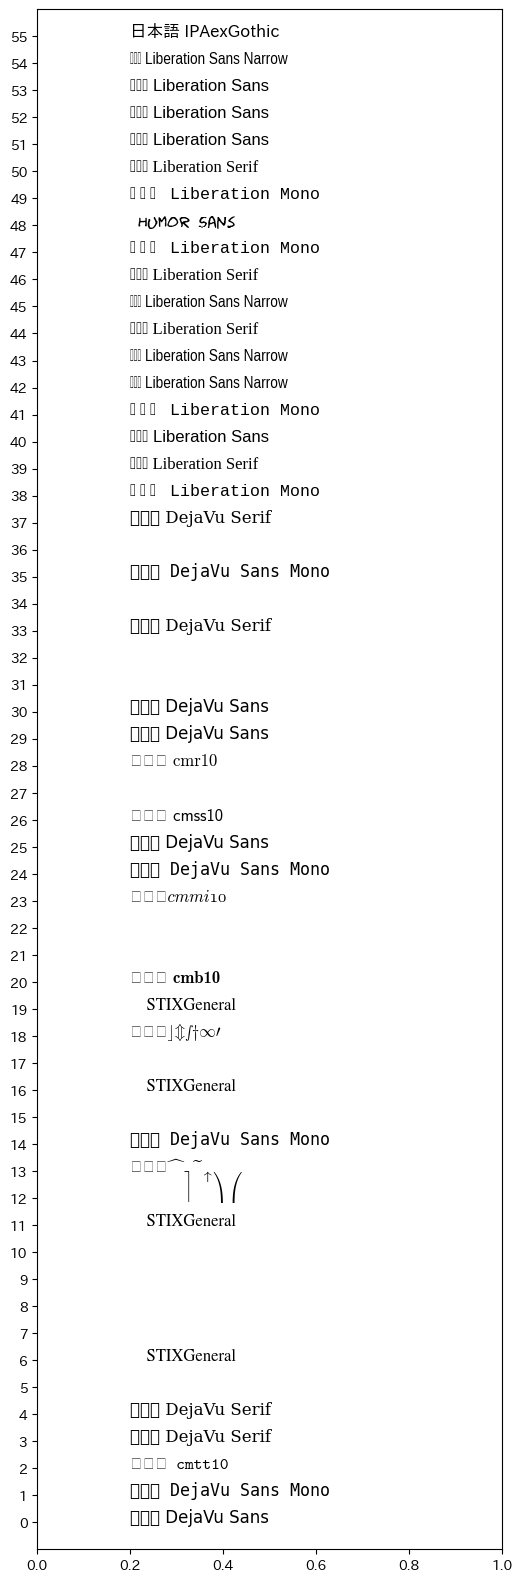

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

fonts = [f.name for f in fm.fontManager.ttflist]

fig = plt.figure(figsize=(6, 20))
ax = fig.add_subplot(1, 1, 1)
ax.set_ylim([-1, len(fonts)])
ax.set_yticks(np.arange(0, len(fonts), 1))

for i, f in enumerate(fonts):
    ax.text(0.2, i,  '日本語 {}'.format(f), fontdict={'family': f, 'fontsize': 12})

plt.show()